In [1]:
import pandas as pd
import numpy as np

In [2]:
data = "data\CustomQuery.xlsx"
df = pd.read_excel(data)

<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\oreva\AppData\Local\Temp\ipykernel_26828\2700685279.py:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  data = "data\CustomQuery.xlsx"


In [3]:
df.head(10)

,Region,Country,IncomeGroup,IDA Status,Financial closure year,Financial closure Month,Project name,RelatedNames,Type of PPI,Subtype of PPI,...,Sponsors Country,Main Revenue Source,Other Revenue Source,MultiLateralSupport,BiLateralSupport,TotalDebtFunding,DebtEquityGrantRatio,ProjectBanks,UnsolicitedProposal,PublicDisclosure
0,East Asia and Pacific,Cambodia,Low income,IDA,2001,May,Kampong Cham City Diesel Plant,NaN,Greenfield project,"Build, operate, and transfer",...,Malaysia,Not Applicable,NaN,No,No,NaN,NaN,EXIM Bank Malaysia (Not Available / Not Availa...,NaN,No
1,East Asia and Pacific,Cambodia,Low income,IDA,2001,April,Kirirom 1 and 3 Hydropower Stations,Kirium Hydro Station Project,Brownfield,"Rehabilitate, operate, and transfer",...,China,Not Applicable,NaN,No,No,NaN,NaN,EX-IM Bank of China (Not Available / Not Avail...,NaN,No
2,East Asia and Pacific,Cambodia,Low income,IDA,2001,April,Kirirom 1 and 3 Hydropower Stations,Kirium Hydro Station Project,Brownfield,"Rehabilitate, operate, and transfer",...,China,Not Applicable,NaN,No,No,NaN,NaN,EX-IM Bank of China (Not Available / Not Avail...,NaN,No
3,East Asia and Pacific,Cambodia,Low income,IDA,2001,September,Siem Reap International Airport (SRIA),NaN,Brownfield,"Rehabilitate, operate, and transfer",...,"France, \n\nCambodia",Not Applicable,NaN,IFC (Loan / $10 Million / 2004),No,NaN,NaN,NaN,NaN,No
4,East Asia and Pacific,Cambodia,Low income,IDA,2001,September,Siem Reap International Airport (SRIA),NaN,Brownfield,"Rehabilitate, operate, and transfer",...,"France, \n\nCambodia",Not Applicable,NaN,IFC (Loan / $10 Million / 2004),No,NaN,NaN,NaN,NaN,No
5,East Asia and Pacific,Cambodia,Low income,IDA,2002,April,Koh Kong Bridge,NaN,Greenfield project,"Build, operate, and transfer",...,"Hong Kong, China",Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No
6,East Asia and Pacific,Cambodia,Low income,IDA,2004,February,Khmer Electric Power,NaN,Greenfield project,"Build, own, and operate",...,Cambodia,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No
7,East Asia and Pacific,Cambodia,Low income,IDA,2004,September,Mondulkiri Province Toll Road,NaN,Greenfield project,"Build, operate, and transfer",...,Cambodia,Not Applicable,NaN,No,No,NaN,NaN,NaN,Yes,No
8,East Asia and Pacific,Cambodia,Low income,IDA,2005,July,Colben Energy,Colben System,Greenfield project,"Build, own, and operate",...,Singapore,Purchase agreements or transmission fees with ...,NaN,No,No,NaN,NaN,Alfa (Not Available / Not Available / $Not Ava...,NaN,No
9,East Asia and Pacific,Cambodia,Low income,IDA,2006,July,Sihanoukville International Airport,"SCA, Société Concessionnaire de l’Aéroport",Brownfield,"Build, rehabilitate, operate, and transfer",...,"France, \n\nCambodia",Not Applicable,NaN,"IFC (Loan / $8 Million / 2007), \n\nIFC (Loan ...",No,NaN,NaN,NaN,NaN,No


In [4]:
df.shape

(6636, 45)

In [5]:
df.columns

Index(['Region', 'Country', 'IncomeGroup', 'IDA Status',
       'Financial closure year', 'Financial closure Month', 'Project name',
       'RelatedNames', 'Type of PPI', 'Subtype of PPI', 'Project status',
       'Primary sector', 'Subsector', 'Segment', 'Location', 'ContractPeriod',
       'GovtGrantingContract', 'DirectGovtSupport', 'DirectGovtSupportValue',
       'InDirectGovtSupport', 'InDirectGovtSupportValue', 'Total Equity',
       'InvestmentYear', 'PercentPrivate', 'FeesToGovernment',
       'PhysicalAssets', 'TotalInvestment', 'CapacityType', 'Capacity',
       'Technology', 'RelatedProjects', 'BidCriteria', 'AwardMethod',
       'NumberOfBids', 'Sponsors', 'Sponsors Country', 'Main Revenue Source',
       'Other Revenue Source', 'MultiLateralSupport', 'BiLateralSupport',
       'TotalDebtFunding', 'DebtEquityGrantRatio', 'ProjectBanks',
       'UnsolicitedProposal', 'PublicDisclosure'],
      dtype='object')

In [6]:
# Convert numerics
NUM_COLS = ['TotalInvestment', 'PhysicalAssets', 'Total Equity',
            'TotalDebtFunding', 'ContractPeriod', 'PercentPrivate']
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
 

In [7]:
#ENGINEER TARGET VARIABLE
# A project is "distressed" if it is Cancelled or Distressed
# This is our binary classification label (0 = healthy, 1 = distressed)
df['distressed'] = df['Project status'].isin(['Cancelled', 'Distressed']).astype(int)
 

In [8]:
filtered_df = df[df['distressed'] == 1]

In [9]:
filtered_df.head(10)

,Region,Country,IncomeGroup,IDA Status,Financial closure year,Financial closure Month,Project name,RelatedNames,Type of PPI,Subtype of PPI,...,Main Revenue Source,Other Revenue Source,MultiLateralSupport,BiLateralSupport,TotalDebtFunding,DebtEquityGrantRatio,ProjectBanks,UnsolicitedProposal,PublicDisclosure,distressed
63,East Asia and Pacific,China,Upper middle income,Non-IDA,2001,February,Funing Wah Sang Gas Project,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
69,East Asia and Pacific,China,Upper middle income,Non-IDA,2001,November,Liuyang Wah Sang Gas Project,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
94,East Asia and Pacific,China,Upper middle income,Non-IDA,2002,June,Anji Xinao Gas Company Limited,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
103,East Asia and Pacific,China,Upper middle income,Non-IDA,2002,June,Feng County Wah Sang Gas Project,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
136,East Asia and Pacific,China,Upper middle income,Non-IDA,2002,November,Suining Wah Sang Gas Project,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
1093,East Asia and Pacific,Indonesia,Lower middle income,Non-IDA,2017,April,Cirebon 2 Coal - Fired Power Plant,NaN,Brownfield,"Build, rehabilitate, operate, and transfer",...,Purchase agreements or transmission fees with ...,NaN,No,"JBIC (Loan / $731 Million / 2017), \n\n Export...",1740.0,80:20,Japan Bank for International Cooperation (JBIC...,Yes,No,1
1160,East Asia and Pacific,Malaysia,Upper middle income,Non-IDA,2000,December,Guthrie Corridor Expressway Sdn Bhd,GCESB,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
1166,East Asia and Pacific,Malaysia,Upper middle income,Non-IDA,2001,August,"Panglima Power, Teluk Gong 2",NaN,Greenfield project,"Build, own, and operate",...,Not Applicable,NaN,No,No,NaN,NaN,Local (Not Available / Not Available / $Not Av...,NaN,No,1
1244,East Asia and Pacific,Philippines,Lower middle income,Non-IDA,2000,October,Subic Bay Terminal,NaN,Brownfield,"Build, rehabilitate, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,NaN,NaN,No,1
1247,East Asia and Pacific,Philippines,Lower middle income,Non-IDA,2001,September,Ninoy Aquino International Airport Terminal 3,PIATCO,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,"ADB (Loan / $80 Million / 1999), \n\nIFC (Loan...",No,NaN,NaN,NaN,NaN,No,1


In [10]:
filtered_df.count()


Region                      129
Country                     129
IncomeGroup                 129
IDA Status                  129
Financial closure year      129
Financial closure Month     129
Project name                129
RelatedNames                 47
Type of PPI                 129
Subtype of PPI              129
Project status              129
Primary sector              129
Subsector                   129
Segment                     129
Location                    126
ContractPeriod               98
GovtGrantingContract        129
DirectGovtSupport           129
DirectGovtSupportValue       14
InDirectGovtSupport         129
InDirectGovtSupportValue      3
Total Equity                 22
InvestmentYear              129
PercentPrivate              126
FeesToGovernment            129
PhysicalAssets              121
TotalInvestment             111
CapacityType                129
Capacity                    129
Technology                   44
RelatedProjects              12
BidCrite

In [11]:
filtered_df.shape

(129, 46)

In [12]:
filtered_df2 = df[df['distressed'] == 0]

In [13]:
filtered_df2.head()

,Region,Country,IncomeGroup,IDA Status,Financial closure year,Financial closure Month,Project name,RelatedNames,Type of PPI,Subtype of PPI,...,Main Revenue Source,Other Revenue Source,MultiLateralSupport,BiLateralSupport,TotalDebtFunding,DebtEquityGrantRatio,ProjectBanks,UnsolicitedProposal,PublicDisclosure,distressed
0,East Asia and Pacific,Cambodia,Low income,IDA,2001,May,Kampong Cham City Diesel Plant,NaN,Greenfield project,"Build, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,EXIM Bank Malaysia (Not Available / Not Availa...,NaN,No,0
1,East Asia and Pacific,Cambodia,Low income,IDA,2001,April,Kirirom 1 and 3 Hydropower Stations,Kirium Hydro Station Project,Brownfield,"Rehabilitate, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,EX-IM Bank of China (Not Available / Not Avail...,NaN,No,0
2,East Asia and Pacific,Cambodia,Low income,IDA,2001,April,Kirirom 1 and 3 Hydropower Stations,Kirium Hydro Station Project,Brownfield,"Rehabilitate, operate, and transfer",...,Not Applicable,NaN,No,No,NaN,NaN,EX-IM Bank of China (Not Available / Not Avail...,NaN,No,0
3,East Asia and Pacific,Cambodia,Low income,IDA,2001,September,Siem Reap International Airport (SRIA),NaN,Brownfield,"Rehabilitate, operate, and transfer",...,Not Applicable,NaN,IFC (Loan / $10 Million / 2004),No,NaN,NaN,NaN,NaN,No,0
4,East Asia and Pacific,Cambodia,Low income,IDA,2001,September,Siem Reap International Airport (SRIA),NaN,Brownfield,"Rehabilitate, operate, and transfer",...,Not Applicable,NaN,IFC (Loan / $10 Million / 2004),No,NaN,NaN,NaN,NaN,No,0


In [14]:
filtered_df2.shape

(6507, 46)

In [15]:
# Govt support binary flags
df['has_direct_support']   = (~df['DirectGovtSupport'].isin(['Not Available', 'Not Applicable'])).astype(int)
df['has_indirect_support'] = (~df['InDirectGovtSupport'].isin(['Not Available', 'Not Applicable'])).astype(int)

In [16]:
# Sub-Saharan Africa flag (highest distress region)
df['is_subsaharan'] = df['Region'].str.contains('Sub-Saharan', na=False).astype(int)


In [17]:
# Brownfield/Divestiture flag (higher distress than Greenfield)
df['is_brownfield_div'] = df['Type of PPI'].isin(['Brownfield', 'Divestiture']).astype(int)
 
# ICT/Transport flag (higher distress than Energy)
df['is_high_risk_sector'] = df['Primary sector'].isin(
    ['Information and communication technology (ICT)', 'Transport']).astype(int)

In [18]:
df.describe()

,Financial closure year,ContractPeriod,Total Equity,InvestmentYear,PercentPrivate,PhysicalAssets,TotalInvestment,TotalDebtFunding,distressed,has_direct_support,has_indirect_support,is_subsaharan,is_brownfield_div,is_high_risk_sector
count,6636.000000,4008.000000,2446.000000,6636.000000,6468.000000,6157.000000,6211.000000,2313.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000,6636.000000
mean,2012.039783,25.360279,94.041719,2012.465491,93.369092,241.895720,285.136695,225.054743,0.019439,0.133665,0.121007,0.094786,0.264165,0.307866
std,6.847433,9.992482,305.453678,6.491535,16.881836,546.249406,782.716583,529.179360,0.138074,0.340318,0.326160,0.292941,0.440921,0.461646
min,2000.000000,1.000000,0.000000,2000.000000,1.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2007.000000,20.000000,4.600000,2008.000000,100.000000,28.800000,36.000000,33.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2012.000000,25.000000,23.200000,2012.000000,100.000000,84.000000,98.400000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2018.000000,30.000000,76.475000,2018.000000,100.000000,229.110000,260.310000,207.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,2024.000000,99.000000,6987.400000,2024.000000,100.000000,14800.000000,35586.500000,13415.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
df.shape

(6636, 51)

In [20]:
df.max

<bound method DataFrame.max of                                               Region   Country IncomeGroup  \
0                              East Asia and Pacific  Cambodia  Low income   
1                              East Asia and Pacific  Cambodia  Low income   
2                              East Asia and Pacific  Cambodia  Low income   
3                              East Asia and Pacific  Cambodia  Low income   
4                              East Asia and Pacific  Cambodia  Low income   
...                                              ...       ...         ...   
6631  Sub-Saharan Africa: Western and Central Africa      Togo  Low income   
6632  Sub-Saharan Africa: Western and Central Africa      Togo  Low income   
6633  Sub-Saharan Africa: Western and Central Africa      Togo  Low income   
6634  Sub-Saharan Africa: Western and Central Africa      Togo  Low income   
6635  Sub-Saharan Africa: Western and Central Africa      Togo  Low income   

     IDA Status  Financial closu

## Exploratory Data Analysis

Four plots: class imbalance + annual distress trend, default rate by region/sector/PPI type, numeric feature distributions split by label, and a correlation heatmap of the engineered binary features.

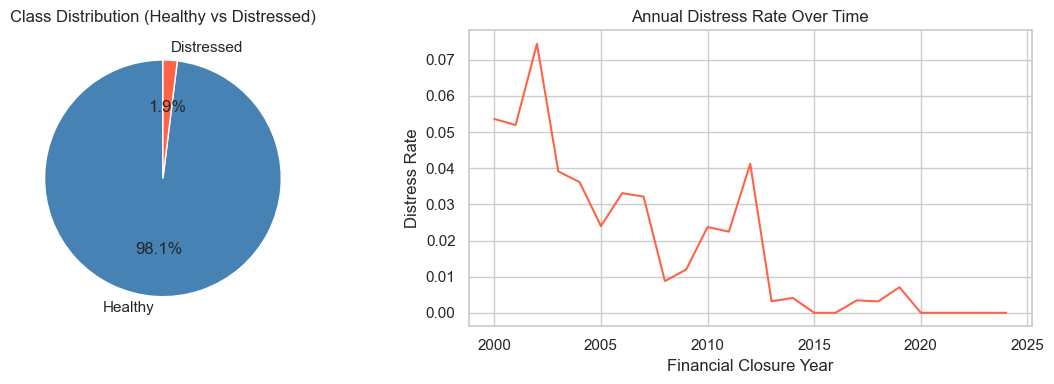

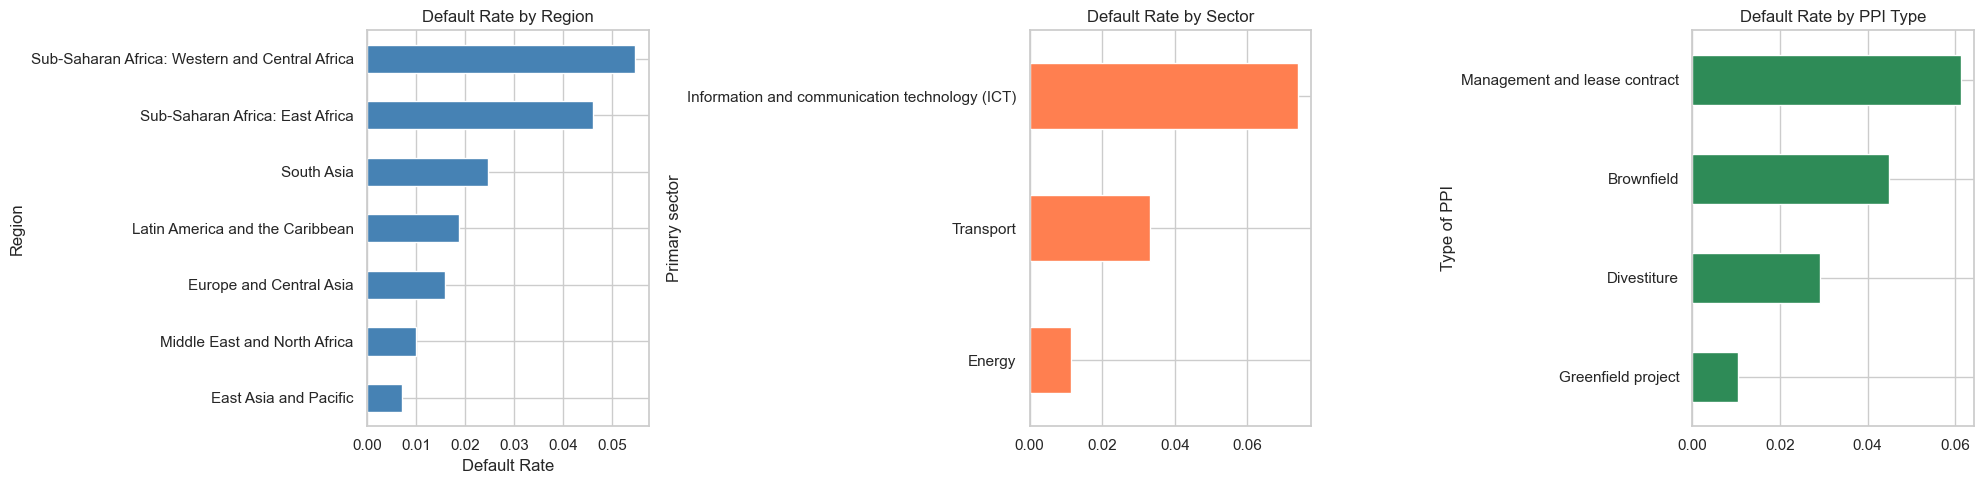

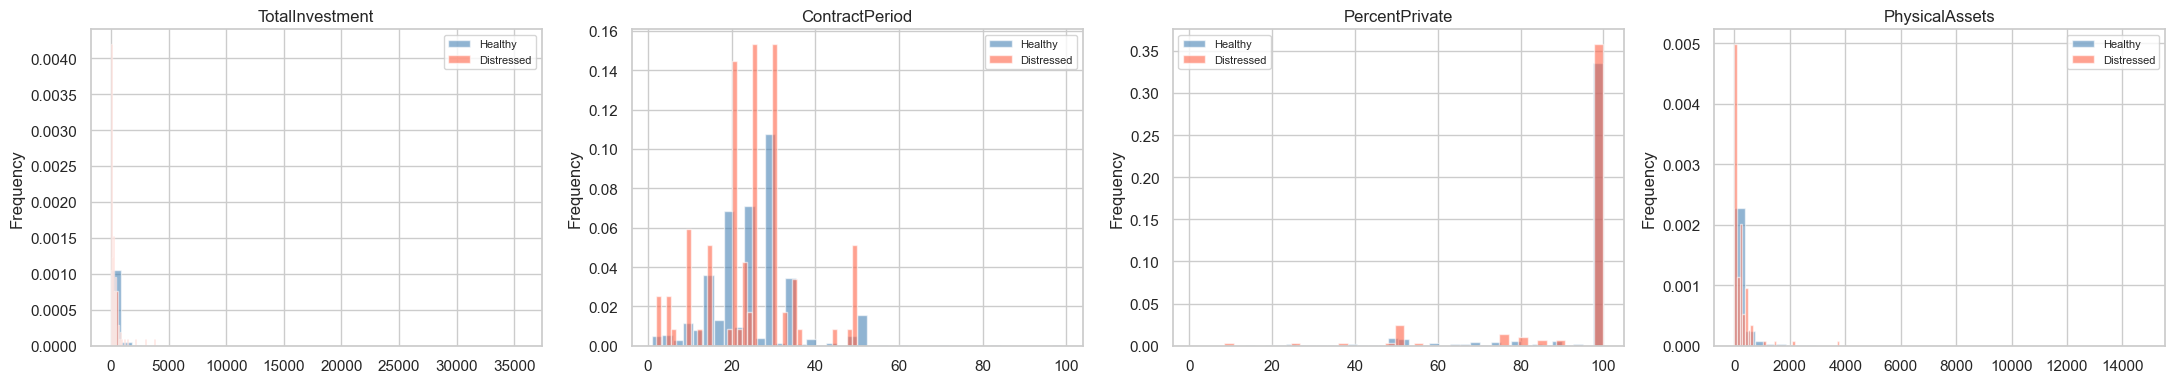

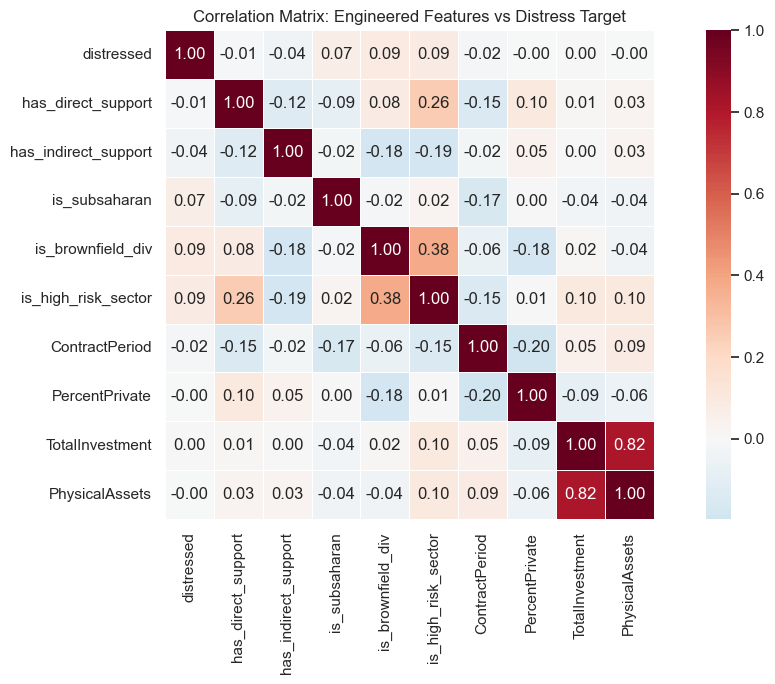

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

# ── 1. Class imbalance ─────────────────────────────────────────────────────
counts = df['distressed'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(counts, labels=['Healthy', 'Distressed'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[0].set_title('Class Distribution (Healthy vs Distressed)')

df.groupby('Financial closure year')['distressed'].agg(['sum', 'count']).assign(
    rate=lambda x: x['sum'] / x['count']
).plot(y='rate', ax=axes[1], color='tomato', legend=False)
axes[1].set_title('Annual Distress Rate Over Time')
axes[1].set_xlabel('Financial Closure Year')
axes[1].set_ylabel('Distress Rate')
plt.tight_layout()
plt.show()

# ── 2. Distress rates by categorical dimensions ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

df.groupby('Region')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Default Rate by Region')
axes[0].set_xlabel('Default Rate')

df.groupby('Primary sector')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Default Rate by Sector')

df.groupby('Type of PPI')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Default Rate by PPI Type')

plt.tight_layout()
plt.show()

# ── 3. Numeric distributions: healthy vs distressed ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, col in zip(axes, ['TotalInvestment', 'ContractPeriod', 'PercentPrivate', 'PhysicalAssets']):
    for label, color, name in [(0, 'steelblue', 'Healthy'), (1, 'tomato', 'Distressed')]:
        df[df['distressed'] == label][col].dropna().plot(
            kind='hist', bins=40, alpha=0.6, color=color, label=name, ax=ax, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── 4. Correlation heatmap (binary features vs target) ────────────────────
hm_cols = ['distressed', 'has_direct_support', 'has_indirect_support',
           'is_subsaharan', 'is_brownfield_div', 'is_high_risk_sector',
           'ContractPeriod', 'PercentPrivate', 'TotalInvestment', 'PhysicalAssets']
hm_cols = [c for c in hm_cols if c in df.columns]
plt.figure(figsize=(11, 7))
sns.heatmap(df[hm_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix: Engineered Features vs Distress Target')
plt.tight_layout()
plt.show()

---
# Part 2: Machine Learning Pipeline

The cells below extend the notebook to build the full credit risk model and Streamlit dashboard. Run from top to bottom — all cells must be executed in order.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print("ML libraries loaded.")

ML libraries loaded.


## Step 1: Additional Feature Engineering

Parse the `DebtEquityGrantRatio` string into a numeric leverage ratio, extract binary presence flags from free-text financing fields, one-hot encode key categoricals, and apply median imputation with missingness indicators.

In [23]:
# ── Parse DebtEquityGrantRatio → numeric leverage (debt share) ────────────
def parse_leverage(s):
    try:
        d, e = str(s).split(':')[:2]
        d, e = float(d), float(e)
        return d / (d + e) if (d + e) > 0 else np.nan
    except Exception:
        return np.nan

df['leverage_ratio']   = df['DebtEquityGrantRatio'].apply(parse_leverage)
df['leverage_missing'] = df['leverage_ratio'].isna().astype(int)

# ── Binary flags from free-text financing columns ─────────────────────────
df['has_multilateral'] = (~df['MultiLateralSupport'].isin(['No', 'Not Available'])).astype(int)
df['has_bilateral']    = (~df['BiLateralSupport'].isin(['No', 'Not Available'])).astype(int)
df['is_unsolicited']   = (df['UnsolicitedProposal'].str.strip() == 'Yes').astype(int)

# ── One-hot encode categoricals ────────────────────────────────────────────
df = pd.get_dummies(df, columns=['AwardMethod', 'IncomeGroup', 'IDA Status'], drop_first=True)

# ── Median imputation + missingness indicators for sparse numeric columns ──
for col in ['TotalInvestment', 'PhysicalAssets', 'TotalDebtFunding', 'ContractPeriod', 'PercentPrivate']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna(df[col].median())

print(f"Dataset shape after full feature engineering: {df.shape}")
df[['leverage_ratio', 'leverage_missing', 'has_multilateral', 'has_bilateral', 'is_unsolicited']].describe()

Dataset shape after full feature engineering: (6636, 67)


,leverage_ratio,leverage_missing,has_multilateral,has_bilateral,is_unsolicited
count,1220.000000,6636.000000,6636.000000,6636.000000,6636.000000
mean,0.755784,0.816154,0.258740,0.174503,0.039180
std,0.210996,0.387387,0.437976,0.379570,0.194038
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.670000,1.000000,0.000000,0.000000,0.000000
50%,0.760000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 2: Exploratory Data Analysis

Understand class imbalance and which categorical/numeric dimensions correlate with distress before modeling.

Class distribution: {0: 6507, 1: 129}
Positive rate: 1.9%



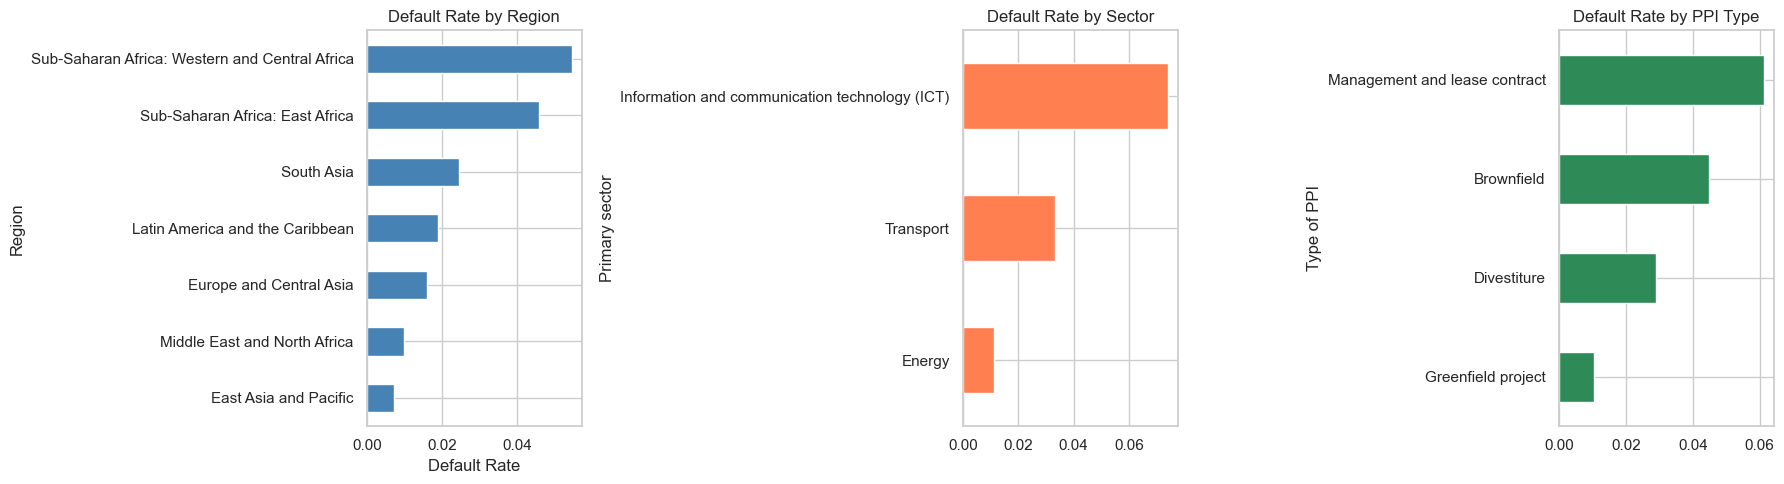

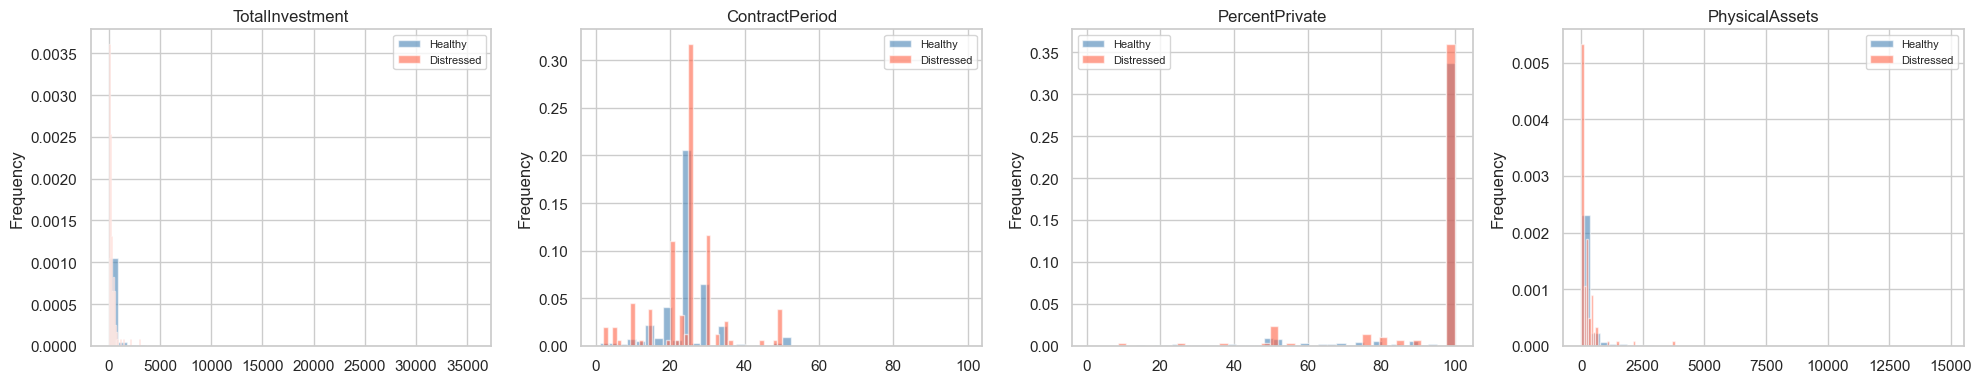

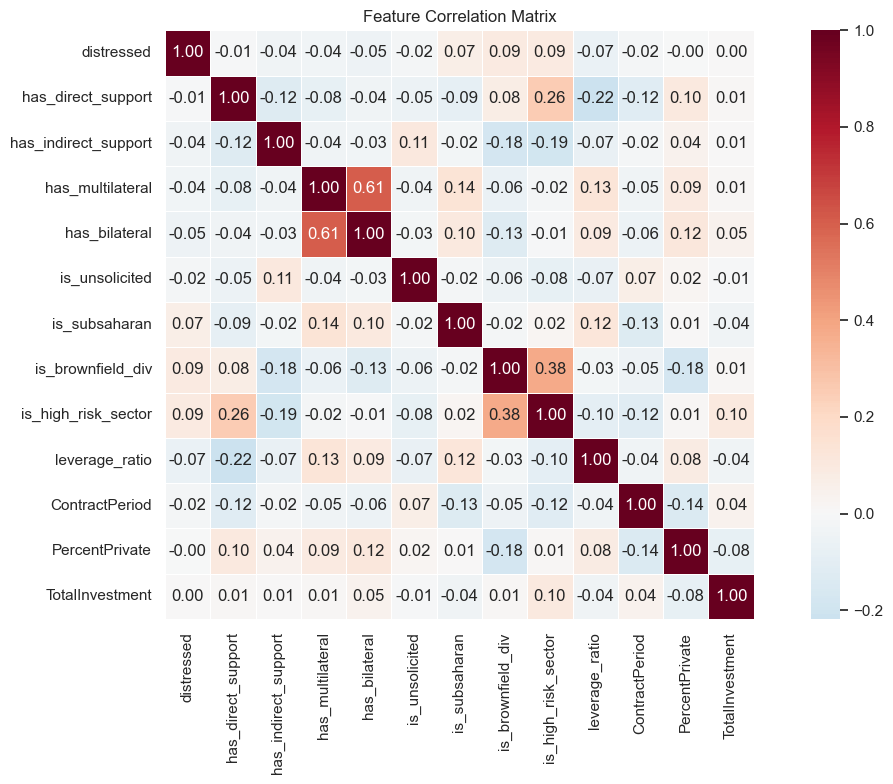

In [24]:
print(f"Class distribution: {df['distressed'].value_counts().to_dict()}")
print(f"Positive rate: {df['distressed'].mean():.1%}\n")

# ── Distress rates by key categorical dimensions ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df.groupby('Region')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Default Rate by Region')
axes[0].set_xlabel('Default Rate')

df.groupby('Primary sector')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Default Rate by Sector')

df.groupby('Type of PPI')['distressed'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Default Rate by PPI Type')

plt.tight_layout()
plt.show()

# ── Numeric distributions: healthy vs distressed ──────────────────────────
num_cols = ['TotalInvestment', 'ContractPeriod', 'PercentPrivate', 'PhysicalAssets']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    for label, color, name in [(0, 'steelblue', 'Healthy'), (1, 'tomato', 'Distressed')]:
        df[df['distressed'] == label][col].dropna().plot(
            kind='hist', bins=40, alpha=0.6, color=color, label=name, ax=ax, density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Correlation heatmap ────────────────────────────────────────────────────
hm_cols = ['distressed', 'has_direct_support', 'has_indirect_support',
           'has_multilateral', 'has_bilateral', 'is_unsolicited',
           'is_subsaharan', 'is_brownfield_div', 'is_high_risk_sector',
           'leverage_ratio', 'ContractPeriod', 'PercentPrivate', 'TotalInvestment']
hm_cols = [c for c in hm_cols if c in df.columns]
plt.figure(figsize=(12, 8))
sns.heatmap(df[hm_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Steps 3 & 4: Model Preparation & Logistic Regression

Build a probability-of-default model. `class_weight='balanced'` compensates for the 1.9% positive rate. Evaluate with AUC-ROC and precision-recall (not accuracy). The coefficient table maps directly to credit risk factors — the output a project finance desk would use.

Feature matrix: (6636, 25)  |  Positives: 129 (1.9%)


5-fold CV AUC-ROC: 0.780 ± 0.056
Test AUC-ROC:       0.736


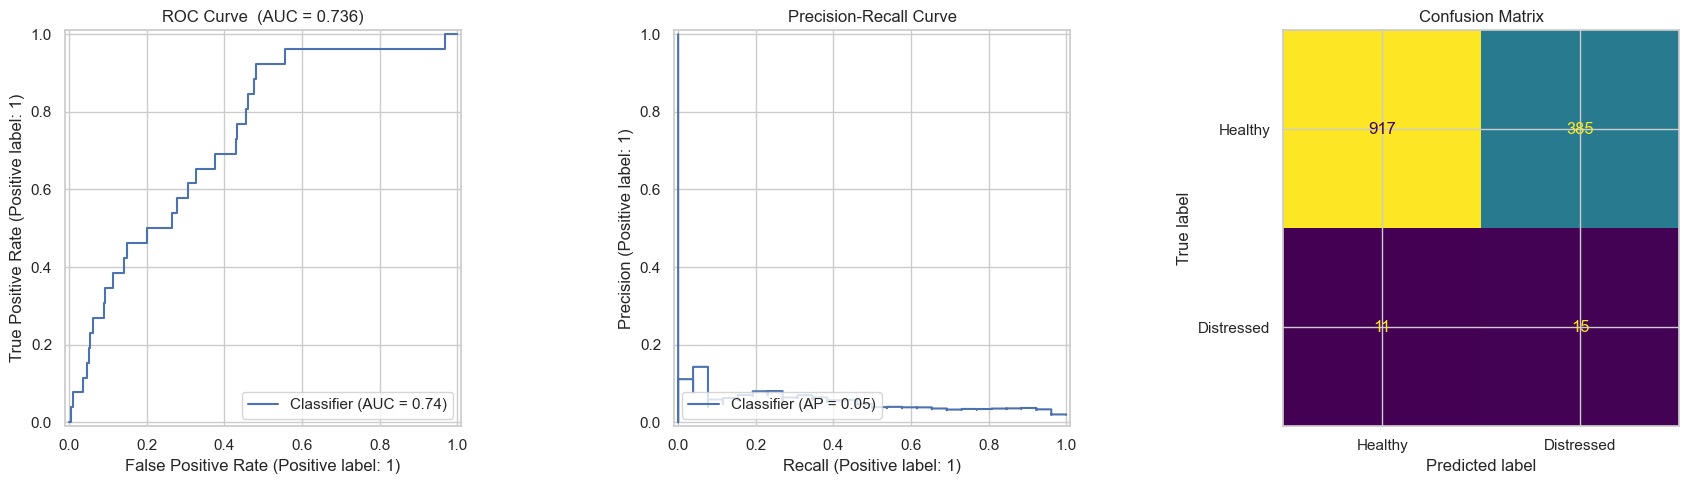

              precision    recall  f1-score   support

     Healthy       0.99      0.70      0.82      1302
  Distressed       0.04      0.58      0.07        26

    accuracy                           0.70      1328
   macro avg       0.51      0.64      0.45      1328
weighted avg       0.97      0.70      0.81      1328


Top risk amplifiers (Odds Ratio > 1 = raises default probability):
                   Feature  Coefficient  Odds Ratio
         is_brownfield_div     0.587920    1.800240
AwardMethod_License scheme     0.572319    1.772373
       is_high_risk_sector     0.535480    1.708268
             is_subsaharan     0.414314    1.513332
            PhysicalAssets     0.305443    1.357226
 AwardMethod_Not Available     0.299791    1.349576
  TotalDebtFunding_missing     0.240351    1.271696
            PercentPrivate     0.210180    1.233900
            ContractPeriod     0.119394    1.126813
   TotalInvestment_missing     0.115728    1.122690


In [25]:
# ── Build feature matrix ──────────────────────────────────────────────────
award_cols  = [c for c in df.columns if c.startswith('AwardMethod_')]
income_cols = [c for c in df.columns if c.startswith('IncomeGroup_')]
ida_cols    = [c for c in df.columns if c.startswith('IDA Status_')]

FEATURES = (
    ['ContractPeriod', 'PercentPrivate', 'TotalInvestment', 'PhysicalAssets',
     'leverage_ratio', 'leverage_missing',
     'has_direct_support', 'has_indirect_support',
     'has_multilateral', 'has_bilateral', 'is_unsolicited',
     'is_subsaharan', 'is_brownfield_div', 'is_high_risk_sector',
     'TotalInvestment_missing', 'TotalDebtFunding_missing']
    + award_cols + income_cols + ida_cols
)
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].fillna(0)
y = df['distressed']
print(f"Feature matrix: {X.shape}  |  Positives: {y.sum()} ({y.mean():.1%})")

# ── Train / test split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Pipeline: scale → logistic regression ─────────────────────────────────
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# ── 5-fold stratified cross-validation ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"5-fold CV AUC-ROC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

pipe.fit(X_train, y_train)
y_pred_proba = pipe.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC-ROC:       {test_auc:.3f}")

# ── Evaluation plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title(f'ROC Curve  (AUC = {test_auc:.3f})')

PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

y_pred = pipe.predict(X_test)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Healthy', 'Distressed']).plot(ax=axes[2], colorbar=False)
axes[2].set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Healthy', 'Distressed']))

# ── Odds ratio table — credit risk factors ────────────────────────────────
odds_df = pd.DataFrame({
    'Feature':     FEATURES,
    'Coefficient': pipe.named_steps['model'].coef_[0],
    'Odds Ratio':  np.exp(pipe.named_steps['model'].coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("\nTop risk amplifiers (Odds Ratio > 1 = raises default probability):")
print(odds_df.head(10).to_string(index=False))

## Step 5: Survival Analysis (Cox Proportional Hazards)

Model *time to distress* rather than just binary outcome. Non-distressed projects are right-censored at their contract period end. The Cox model produces hazard ratios that show how each factor accelerates or delays failure.

Survival dataset: (1220, 11)  (dropped 5416 rows with NaN)


<lifelines.CoxPHFitter: fitted with 1220 total observations, 1217 right-censored observations>
             duration col = 'duration'
                event col = 'distressed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1220
number of events observed = 3
   partial log-likelihood = -20.95
         time fit was run = 2026-05-05 12:01:15 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
ContractPeriod       0.00      1.00      0.01           -0.03            0.03                0.97                1.03
PercentPrivate      -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
TotalInvestment      0.00      1.00      0.00           -0.00            0.00                1.00                1.00
has_direct_support  -0.03      0.97      0.29           -0.60            0.55                0.55                1.73
has_multilateral    -0.05      0.95      0.18           -0.40            0.30                0.67                1.35
is_subsaharan        0.03      1.03      0.25           -0.45            0.52                0.64                1.68
is_brownfield_div    0.09      1.09      0.24           -0.39            0.57                0.68                1.76
is_high_risk_sector  0.01      1.01      0.21           -0.39            0.41                0.67                1.51
leverage_ratio      -0.15      0.86      0.42           -0.99            0.68                0.37                1.96

                     cmp to     z    p  -log2(p)
covariate                                       
ContractPeriod         0.00  0.19 0.85      0.23
PercentPrivate         0.00 -0.52 0.60      0.73
TotalInvestment        0.00  0.21 0.83      0.26
has_direct_support     0.00 -0.10 0.92      0.11
has_multilateral       0.00 -0.26 0.79      0.34
is_subsaharan          0.00  0.14 0.89      0.17
is_brownfield_div      0.00  0.37 0.71      0.49
is_high_risk_sector    0.00  0.05 0.96      0.06
leverage_ratio         0.00 -0.37 0.71      0.48
---
Concordance = 0.95
Partial AIC = 59.91
log-likelihood ratio test = 0.72 on 9 df
-log2(p) of ll-ratio test = 0.00

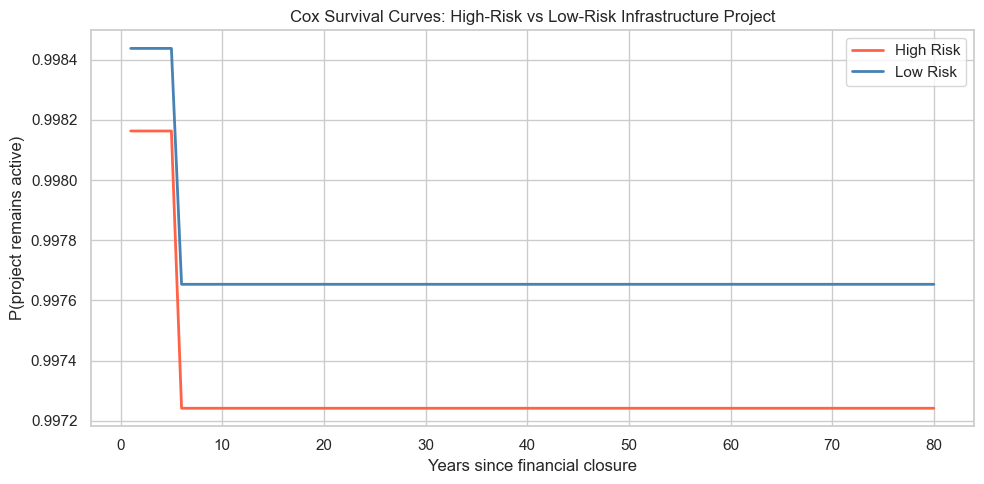

In [26]:
from lifelines import CoxPHFitter

# Duration: years from financial closure to distress event, or censored at contract end
df['duration'] = np.where(
    df['distressed'] == 1,
    (df['InvestmentYear'] - df['Financial closure year']).clip(lower=1),
    df['ContractPeriod'].clip(lower=1)
)

SURVIVAL_FEATURES = ['duration', 'distressed',
                     'ContractPeriod', 'PercentPrivate', 'TotalInvestment',
                     'has_direct_support', 'has_multilateral',
                     'is_subsaharan', 'is_brownfield_div', 'is_high_risk_sector',
                     'leverage_ratio']

cox_df = df[SURVIVAL_FEATURES].dropna()
print(f"Survival dataset: {cox_df.shape}  (dropped {len(df) - len(cox_df)} rows with NaN)")

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col='duration', event_col='distressed')
cph.print_summary()

# ── Survival curves: high-risk vs low-risk project profiles ───────────────
fig, ax = plt.subplots(figsize=(10, 5))

high_risk = pd.DataFrame([{
    'ContractPeriod': 25, 'PercentPrivate': 100, 'TotalInvestment': 200,
    'has_direct_support': 0, 'has_multilateral': 0,
    'is_subsaharan': 1,      'is_brownfield_div': 1, 'is_high_risk_sector': 1,
    'leverage_ratio': 0.8
}])
low_risk = pd.DataFrame([{
    'ContractPeriod': 25, 'PercentPrivate': 100, 'TotalInvestment': 200,
    'has_direct_support': 1, 'has_multilateral': 1,
    'is_subsaharan': 0,      'is_brownfield_div': 0, 'is_high_risk_sector': 0,
    'leverage_ratio': 0.5
}])

cph.predict_survival_function(high_risk).rename(columns={0: 'High Risk'}).plot(ax=ax, color='tomato',    linewidth=2)
cph.predict_survival_function(low_risk).rename(columns={0:  'Low Risk'}).plot(ax=ax,  color='steelblue', linewidth=2)
ax.set_xlabel('Years since financial closure')
ax.set_ylabel('P(project remains active)')
ax.set_title('Cox Survival Curves: High-Risk vs Low-Risk Infrastructure Project')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Save Model Artifacts

Serialize the trained pipeline, feature list, odds ratio table, and Cox model to `model/` so the Streamlit dashboard can load them without re-running this notebook.

In [27]:
import os
os.makedirs('model', exist_ok=True)

joblib.dump(pipe,     'model/logistic_model.pkl')
joblib.dump(FEATURES, 'model/features.pkl')
joblib.dump(odds_df,  'model/odds_ratios.pkl')
joblib.dump(cph,      'model/cox_model.pkl')

# Export processed data for the Streamlit dashboard
export_cols = ['Region', 'Country', 'Primary sector', 'Type of PPI',
               'Financial closure year', 'Project status', 'distressed'] + FEATURES
df[[c for c in export_cols if c in df.columns]].to_parquet('model/processed_data.parquet', index=False)

print("Artifacts saved:")
for fname in sorted(os.listdir('model')):
    size = os.path.getsize(os.path.join('model', fname))
    print(f"  model/{fname}  ({size:,} bytes)")

Artifacts saved:
  model/cox_model.pkl  (153,403 bytes)
  model/features.pkl  (591 bytes)
  model/logistic_model.pkl  (2,945 bytes)
  model/odds_ratios.pkl  (2,355 bytes)
  model/processed_data.parquet  (99,403 bytes)
